In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import train_test_split_edges, negative_sampling
from torch_geometric.transforms import NormalizeFeatures
from sklearn.metrics import roc_auc_score, average_precision_score

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Koristimo:", device)

Koristimo: cpu


In [9]:
dataset = Planetoid(root='./data', name='Cora', transform=NormalizeFeatures())
data = dataset[0]
data = train_test_split_edges(data)

data = data.to(device) #prebacuje sve tenzore na GPU ako postoji, inače ostaje na CPU

print("Trening grane:    ", data.train_pos_edge_index.shape[1])
print("Validacione grane:", data.val_pos_edge_index.shape[1])
print("Test grane:       ", data.test_pos_edge_index.shape[1])

/tmp/ipykernel_32477/1909418050.py:3: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  data = train_test_split_edges(data)


Trening grane:     8976
Validacione grane: 263
Test grane:        527


In [10]:
from torch_geometric.nn import GCNConv #sloj GCN

class GAE(nn.Module):
    def __init__(self, in_channels, hid_channels, out_channels):
        super().__init__()

        self.conv1 = GCNConv(in_channels, hid_channels)
        self.conv2 = GCNConv(hid_channels, out_channels)

    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)

        return x

    def decode(self, z, edge_label_index):
        return(z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim = -1)

    def decode_all(self, z):
        prob_adj = z @ z.t()

        prob_adj = prob_adj.sigmoid()

        return (prob_adj > 0.97).nonzero(as_tuple = false).t()

In [11]:
input_channels = dataset.num_features
hidden_channels = 64
output_channels = 32

model = GAE(
    in_channels=input_channels,
    hid_channels=hidden_channels,
    out_channels=output_channels
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

In [12]:
def train():
    model.train() #stavlja model u training mode
    optimizer.zero_grad()
    
    # 1. Enkodujemo graf -> dobijamo embeddinge
    z = model.encode(data.x, data.train_pos_edge_index)
    
    # 2. Generišemo negativne primere (parovi bez grane)
    neg_edge_index = negative_sampling(
        edge_index=data.train_pos_edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=data.train_pos_edge_index.shape[1]
    )
    # negative_sampling nasumično bira parove čvorova za koje grana NE postoji
    # num_neg_samples = broj pozitivnih grana -> balansiran dataset
    
    # 3. Spoji pozitivne i negativne grane
    edge_index = torch.cat([data.train_pos_edge_index, neg_edge_index], dim=1)
    # dim=1 -> spajamo po kolonama (svaka grana je jedna kolona)
    
    # 4. Napravi labele: 1 za pozitivne, 0 za negativne
    labels = torch.cat([
        torch.ones(data.train_pos_edge_index.shape[1]),
        torch.zeros(neg_edge_index.shape[1])
    ]).to(device)
    
    # 5. Dekoduj -> dobij score za svaku granu
    out = model.decode(z, edge_index)
    
    # 6. Izračunaj gubitak i uradi backprop
    loss = criterion(out, labels)
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [13]:
@torch.no_grad()
def evaluate(pos_edge_index, neg_edge_index):
    model.eval()
    z = model.encode(data.x, data.train_pos_edge_index)
    
    # Spoji pozitivne i negativne test grane
    edge_index = torch.cat([pos_edge_index, neg_edge_index], dim=1)
    
    # Dobij score-ove i primeni sigmoid
    out = model.decode(z, edge_index).sigmoid().cpu().numpy()
    
    # Napravi labele
    labels = torch.cat([
        torch.ones(pos_edge_index.shape[1]),
        torch.zeros(neg_edge_index.shape[1])
    ]).numpy()
    
    auc = roc_auc_score(labels, out)
    ap  = average_precision_score(labels, out)
    return auc, ap

In [14]:
# Generiši negativne primere za val i test (jednom, pa koristi stalno)
val_neg  = negative_sampling(data.val_pos_edge_index,  data.num_nodes, data.val_pos_edge_index.shape[1])
test_neg = negative_sampling(data.test_pos_edge_index, data.num_nodes, data.test_pos_edge_index.shape[1])

# Trening petlja
best_val_auc = 0
for epoch in range(1, 201):
    loss = train()
    
    if epoch % 10 == 0:
        val_auc, val_ap = evaluate(data.val_pos_edge_index, val_neg)
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}")
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), 'best_gae_model.pt')

# Finalna evaluacija na test skupu
model.load_state_dict(torch.load('best_gae_model.pt'))
test_auc, test_ap = evaluate(data.test_pos_edge_index, test_neg)
print(f"\n=== FINALNI REZULTATI ===")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test AP:  {test_ap:.4f}")

Epoch 010 | Loss: 0.6648 | Val AUC: 0.7161 | Val AP: 0.7569
Epoch 020 | Loss: 0.5999 | Val AUC: 0.7933 | Val AP: 0.8139
Epoch 030 | Loss: 0.5154 | Val AUC: 0.8205 | Val AP: 0.8318
Epoch 040 | Loss: 0.4804 | Val AUC: 0.8744 | Val AP: 0.8779
Epoch 050 | Loss: 0.4722 | Val AUC: 0.8884 | Val AP: 0.8909
Epoch 060 | Loss: 0.4620 | Val AUC: 0.8917 | Val AP: 0.8985
Epoch 070 | Loss: 0.4538 | Val AUC: 0.8995 | Val AP: 0.9065
Epoch 080 | Loss: 0.4474 | Val AUC: 0.9115 | Val AP: 0.9185
Epoch 090 | Loss: 0.4401 | Val AUC: 0.9176 | Val AP: 0.9245
Epoch 100 | Loss: 0.4394 | Val AUC: 0.9157 | Val AP: 0.9197
Epoch 110 | Loss: 0.4325 | Val AUC: 0.9143 | Val AP: 0.9192
Epoch 120 | Loss: 0.4364 | Val AUC: 0.9107 | Val AP: 0.9154
Epoch 130 | Loss: 0.4314 | Val AUC: 0.9134 | Val AP: 0.9203
Epoch 140 | Loss: 0.4349 | Val AUC: 0.9126 | Val AP: 0.9160
Epoch 150 | Loss: 0.4304 | Val AUC: 0.9146 | Val AP: 0.9190
Epoch 160 | Loss: 0.4300 | Val AUC: 0.9144 | Val AP: 0.9210
Epoch 170 | Loss: 0.4280 | Val AUC: 0.91

In [15]:
# ============================================================
# EKSPERIMENTI SA HIPERPARAMETRIMA
# ============================================================

configs = [
    {"hidden": 64,  "out": 32, "lr": 0.01,  "epochs": 200},  # originalna
    {"hidden": 128, "out": 64, "lr": 0.01,  "epochs": 200},  # veći embedding
    {"hidden": 32,  "out": 16, "lr": 0.01,  "epochs": 200},  # manji embedding
    {"hidden": 64,  "out": 32, "lr": 0.001, "epochs": 300},  # manji lr
]

results = []

for cfg in configs:
    # Svaki put reinicijalizuj model i optimizer
    torch.manual_seed(42)
    model_exp = GAE(
        in_channels=input_channels,
        hid_channels=cfg["hidden"],
        out_channels=cfg["out"]
    ).to(device)
    optimizer_exp = torch.optim.Adam(model_exp.parameters(), lr=cfg["lr"])

    # Trening
    for epoch in range(1, cfg["epochs"] + 1):
        model_exp.train()
        optimizer_exp.zero_grad()
        z = model_exp.encode(data.x, data.train_pos_edge_index)
        neg_edge_index = negative_sampling(
            edge_index=data.train_pos_edge_index,
            num_nodes=data.num_nodes,
            num_neg_samples=data.train_pos_edge_index.shape[1]
        )
        edge_index = torch.cat([data.train_pos_edge_index, neg_edge_index], dim=1)
        labels = torch.cat([
            torch.ones(data.train_pos_edge_index.shape[1]),
            torch.zeros(neg_edge_index.shape[1])
        ]).to(device)
        out = model_exp.decode(z, edge_index)
        loss = criterion(out, labels)
        loss.backward()
        optimizer_exp.step()

    # Evaluacija na test skupu
    @torch.no_grad()
    def eval_exp(m, pos_ei, neg_ei):
        m.eval()
        z = m.encode(data.x, data.train_pos_edge_index)
        ei = torch.cat([pos_ei, neg_ei], dim=1)
        out = m.decode(z, ei).sigmoid().cpu().numpy()
        lbl = torch.cat([
            torch.ones(pos_ei.shape[1]),
            torch.zeros(neg_ei.shape[1])
        ]).numpy()
        return roc_auc_score(lbl, out), average_precision_score(lbl, out)

    test_auc, test_ap = eval_exp(model_exp, data.test_pos_edge_index, test_neg)
    results.append({
        "hidden": cfg["hidden"],
        "out": cfg["out"],
        "lr": cfg["lr"],
        "epochs": cfg["epochs"],
        "Test AUC": round(test_auc, 4),
        "Test AP":  round(test_ap, 4)
    })
    print(f"hidden={cfg['hidden']:3d}, out={cfg['out']:2d}, lr={cfg['lr']} → AUC={test_auc:.4f}, AP={test_ap:.4f}")

hidden= 64, out=32, lr=0.01 → AUC=0.9068, AP=0.9133
hidden=128, out=64, lr=0.01 → AUC=0.9064, AP=0.9190
hidden= 32, out=16, lr=0.01 → AUC=0.8956, AP=0.9034
hidden= 64, out=32, lr=0.001 → AUC=0.8397, AP=0.8320


In [17]:
import pandas as pd

df = pd.DataFrame(results)
df = df.sort_values("Test AUC", ascending=False).reset_index(drop=True)
display(df)

,hidden,out,lr,epochs,Test AUC,Test AP
0,64,32,0.010,200,0.9068,0.9133
1,128,64,0.010,200,0.9064,0.9190
2,32,16,0.010,200,0.8956,0.9034
3,64,32,0.001,300,0.8397,0.8320


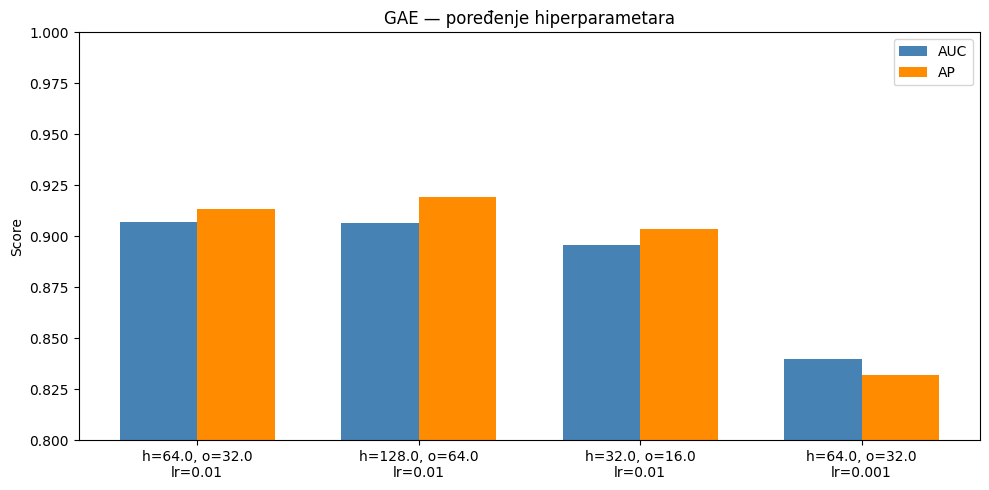

In [18]:
import matplotlib.pyplot as plt

labels_cfg = [f"h={r['hidden']}, o={r['out']}\nlr={r['lr']}" for _, r in df.iterrows()]
auc_vals   = df["Test AUC"].tolist()
ap_vals    = df["Test AP"].tolist()

x = range(len(labels_cfg))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], auc_vals, width, label='AUC', color='steelblue')
ax.bar([i + width/2 for i in x], ap_vals,  width, label='AP',  color='darkorange')

ax.set_ylabel("Score")
ax.set_title("GAE — poređenje hiperparametara")
ax.set_xticks(list(x))
ax.set_xticklabels(labels_cfg)
ax.set_ylim(0.8, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig('../results/gae_hyperparams.png', dpi=150)
plt.show()